## Astro Physics Collaboration Network Tutorial


In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from node2vec import Node2Vec
from sklearn.decomposition import PCA
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [20]:
import utils
import generate_synthetic_graph_lesson9 as synthetic
file_path = synthetic.get_synthetic_graph_file_path()
G = nx.read_graphml(file_path)
utils.print_graph_info(G)

# %%

Not running in Colab. Using local folder: /Users/boris/Documents/teaching/ML on graphs/ML-on-Graphs/data
Using data folder: /Users/boris/Documents/teaching/ML on graphs/ML-on-Graphs/data
ZIP file already exists.
Extraction complete.
File /Users/boris/Documents/teaching/ML on graphs/ML-on-Graphs/data/ca-AstroPh_sample.graphml already exists
Graph is undirected and unweighted.
Graph is connected.
Number of nodes:	  4,790
Number of edges:	 77,113
Density:		0.007


### Dataset Information
This dataset is based on the Astro Physics collaboration network dataset from the arXiv.

**Astro Physics Collaboration Network**

- **Description:**  
  The Astro Physics collaboration network dataset is from the arXiv and captures scientific collaborations between authors who have submitted papers to the Astro Physics category. An undirected edge is created between authors if they have co-authored a paper. For papers co-authored by *k* authors, the dataset generates a complete subgraph on *k* nodes.

- **Time Period:**  
  January 1993 to April 2003 (124 months)

I took a sample of about 5000 nodes from the original dataset and simulated node ambiguity by combining some pairs of nodes into a new node.

In [21]:
[(n, d) for (n, d) in G.nodes(data=True)][0:3]

[('65541', {'label': 'not ambiguous'}),
 ('13', {'label': 'not ambiguous'}),
 ('17', {'label': 'not ambiguous'})]

In [22]:
df_graph_data = pd.DataFrame([
    [n, d['label']]
    for n, d in G.nodes(data=True)
],
columns=['node_id', 'label']
)
df_graph_data.head()

# %%

,node_id,label
0,65541,not ambiguous
1,13,not ambiguous
2,17,not ambiguous
3,131091,not ambiguous
4,26,not ambiguous


In [23]:
df_graph_data.label.value_counts(normalize=True)

label
not ambiguous    0.958038
ambiguous        0.041962
Name: proportion, dtype: float64

About 1% of the nodes are labeled as "ambigous", our final goal will be to predict this label.

## Section 1: Preparing Graph Data for Supervised Learning Tasks


### Objectives
- Understand the process of cleaning and preparing graph data for supervised learning.
- Learn to load, inspect, and preprocess the Astro Physics collaboration network dataset.


### Introduction
In this section, we overview the data preparation steps required for supervised learning on graph data. This includes loading the dataset, cleaning the data (handling missing values and noise), and splitting the data into training and testing sets. Proper preparation is essential for achieving robust model performance.


### Key Points
- Data ingestion: Load the dataset and verify its structure.
- Data cleaning: Remove noise and handle missing or inconsistent values.
- Data splitting: Partition the dataset into training and testing sets.


### Code Examples
Below are examples of code to load the dataset, inspect basic graph statistics, and visualize properties such as the degree distribution.


Text(0.5, 1.0, 'Degree Distribution of Astro Physics Collaboration Network')

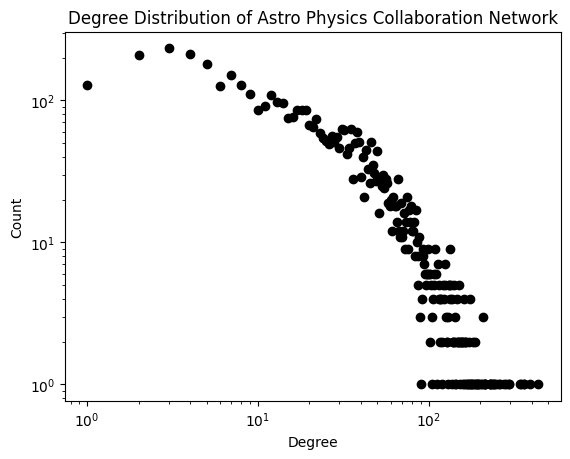

In [24]:
degrees = [G.degree(n) for n in G.nodes()]
ax = utils.log_log_plot(degrees)
ax.set_title("Degree Distribution of Astro Physics Collaboration Network")

### Quiz
1. What are the primary steps involved in preparing graph data for supervised learning tasks?  
2. Why is data cleaning important when working with graph datasets like the Astro Physics network?


### Practical Activities
- **Activity 1:** Write code to clean the dataset by identifying and removing isolated nodes, and extracting only the giant component. Observe how this affects the graph structure.

(hint: look at the `utils` module)


Number of isolated nodes: 0
Cleaned Graph: Number of nodes: 4790
Cleaned Graph: Number of edges: 77113


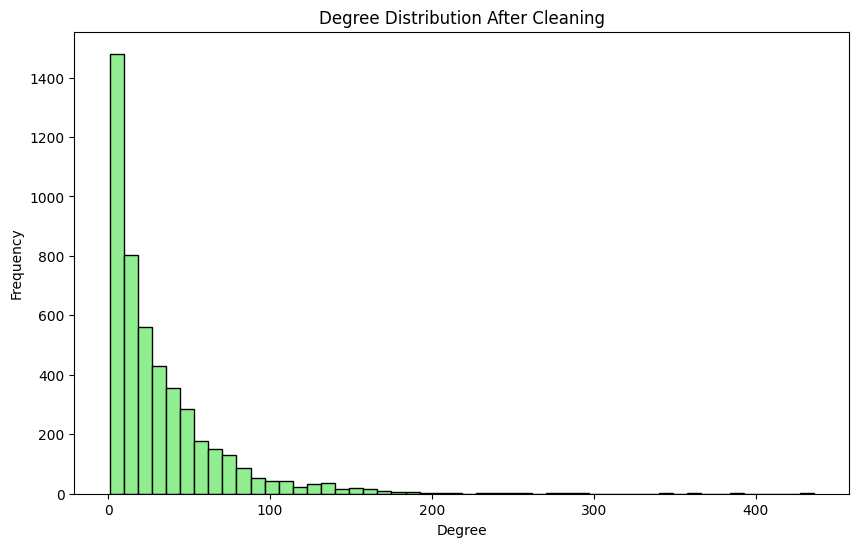

In [25]:
## Answer
# Practical Activity: Remove isolated nodes and verify the cleaned graph.
isolated_nodes = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated_nodes))

# Remove isolated nodes from the graph
G_cleaned = G.copy()
G_cleaned.remove_nodes_from(isolated_nodes)
print("Cleaned Graph: Number of nodes:", G_cleaned.number_of_nodes())
print("Cleaned Graph: Number of edges:", G_cleaned.number_of_edges())

# Visualize the degree distribution of the cleaned graph
cleaned_degrees = [G_cleaned.degree(n) for n in G_cleaned.nodes()]

plt.figure(figsize=(10, 6))
plt.hist(cleaned_degrees, bins=50, color="lightgreen", edgecolor="black")
plt.title("Degree Distribution After Cleaning")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

## Section 2: Feature Engineering and Graph Representation for Supervised Learning


### Objectives
- Learn to extract meaningful features from graph data.
- Understand how to represent graph nodes and edges for supervised learning models.


### Introduction
This section focuses on transforming the Astro Physics collaboration network into feature-rich representations suitable for supervised learning. We will explore techniques such as generating graph embeddings and manually computing graph metrics like degree centrality and clustering coefficients. These features capture different aspects of the graph structure, enabling more effective learning.


### Key Points
- **Graph Embeddings:** Convert nodes into low-dimensional vectors using methods like Node2Vec.
- **Manual Feature Extraction:** Compute graph metrics such as degree centrality and clustering coefficient.
- **Feature Combination:** Integrate multiple feature sources to enhance the input for supervised learning models.


### Code Examples
Below are code examples for generating node embeddings and computing manual graph metrics from the Astro Physics collaboration network. We also visualize the extracted features using PCA.


**Practical Activity:** Write code to generate node embeddings using Node2Vec. Use 32 dimensions, walk length 5, and num_walks 10

In [26]:
## answer
# Should take about 30-40 seconds to run
# ---------------------------
# Generate Node Embeddings using Node2Vec with reduced parameters
# ---------------------------
node2vec = Node2Vec(G, dimensions=32, walk_length=5, num_walks=10, workers=2)
model = node2vec.fit(window=3, min_count=1)

# Extract embeddings into a matrix for nodes in the subgraph.
nodes = list(G.nodes())
embeddings = np.array([model.wv[str(node)] for node in nodes if str(node) in model.wv])
df_node2vec_features = pd.DataFrame(embeddings)
print("Node Embeddings Shape:", embeddings.shape)


Computing transition probabilities:   0%|          | 0/4790 [00:00<?, ?it/s]

Generating walks (CPU: 2): 100%|██████████| 5/5 [00:00<00:00, 15.41it/s]


Node Embeddings Shape: (4790, 32)


**Practical Activity:** Compute PCA with 5 components and visualize the results using seaborn `pairplot`.

In [27]:
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
embeddings_reduced = pca.fit_transform(embeddings)

df_node2vec_features_pca = pd.DataFrame(embeddings_reduced, columns=[f'PC{i}' for i in range(5)])
df_node2vec_features_pca['label'] = df_graph_data['label'].values
df_node2vec_features_pca.head()

,PC0,PC1,PC2,PC3,PC4,label
0,-0.201148,-0.222167,-0.026699,-0.173231,0.033873,not ambiguous
1,0.029269,-0.067794,0.055632,-0.078942,0.001210,not ambiguous
2,-0.057150,-0.033260,0.004701,0.124448,0.087917,not ambiguous
3,0.025171,0.050089,0.191405,-0.484040,-0.085606,not ambiguous
4,-0.218166,-0.073860,0.088228,0.066571,-0.013429,not ambiguous


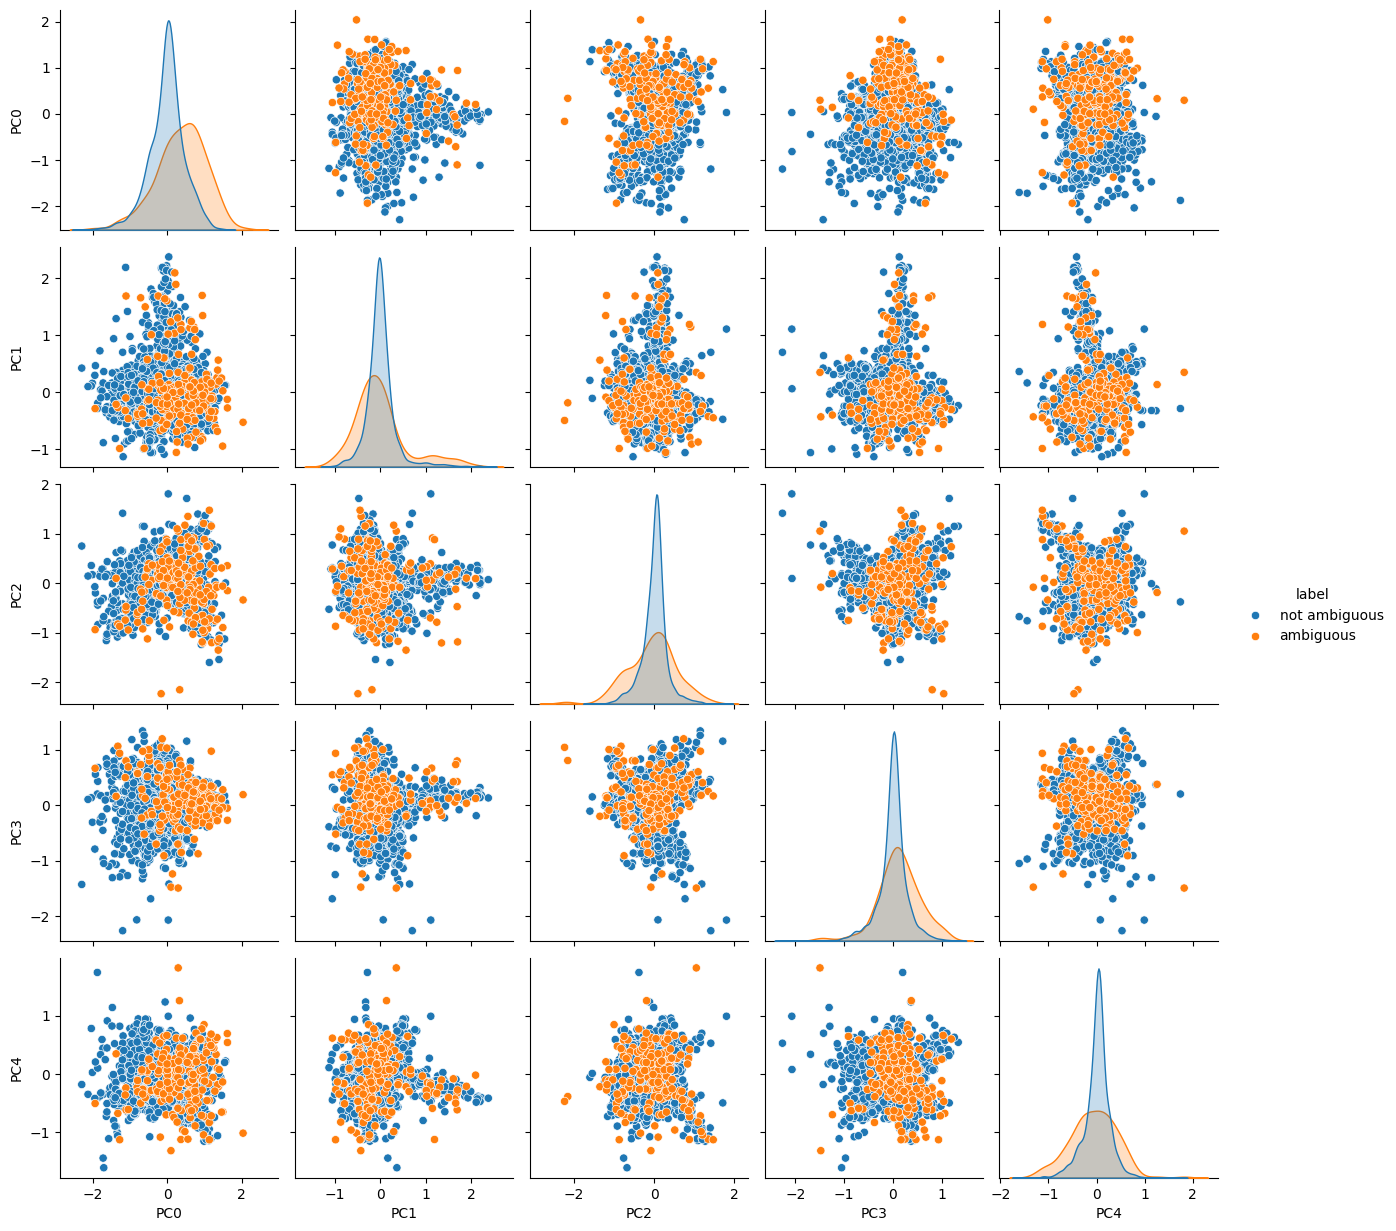

In [28]:
sns.pairplot(
    df_node2vec_features_pca,
    hue="label",
    diag_kind="kde",  # Use KDE plots on diagonal
    diag_kws={"common_norm": False},  # Normalize each KDE separately
)

In [29]:
# Compute Manual Graph Metrics on the Subgraph:
# Centrality metrics:
# - Degree centrality
# - Clustering coefficient
# - [CANCELED: this is too slow] Betweenness centrality
# - PageRank
# Connectivity metrics:
#  - log(Number of neighbors+1)
#  - log(Number of triangles+1)

df_manual_features = pd.DataFrame()
deg_centrality = nx.degree_centrality(G)
clust_coeff = nx.clustering(G)
# betweenness_centrality = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)
num_neighbors = dict(G.degree())
num_triangles = nx.triangles(G)
nodes = list(G.nodes())
df_manual_features = pd.DataFrame(
    {
        "node_id": nodes,
        "degree_centrality": [deg_centrality[node] for node in nodes],
        "clustering_coefficient": [clust_coeff[node] for node in nodes],
        # "betweenness_centrality": [betweenness_centrality[node] for node in nodes],
        "pagerank": [pagerank[node] for node in nodes],
        "log1p_num_neighbors": np.log1p([num_neighbors[node] for node in nodes]),
        "log1p_num_triangles": np.log1p([num_triangles[node] for node in nodes]),
    }
)

# Set node_id as index
df_manual_features.set_index("node_id", inplace=True)
df_manual_features['label'] = df_graph_data['label'].values

print(f"Manual features computed for {len(df_manual_features)} nodes")
df_manual_features.head()

Manual features computed for 4790 nodes


,degree_centrality,clustering_coefficient,pagerank,log1p_num_neighbors,log1p_num_triangles,label
node_id,,,,,,
65541,0.001044,1.000000,0.000084,1.791759,2.397895,not ambiguous
13,0.001044,0.600000,0.000077,1.791759,1.945910,not ambiguous
17,0.000209,0.000000,0.000037,0.693147,0.000000,not ambiguous
131091,0.012529,0.647913,0.000316,4.110874,6.977281,not ambiguous
26,0.000626,0.333333,0.000073,1.386294,0.693147,not ambiguous


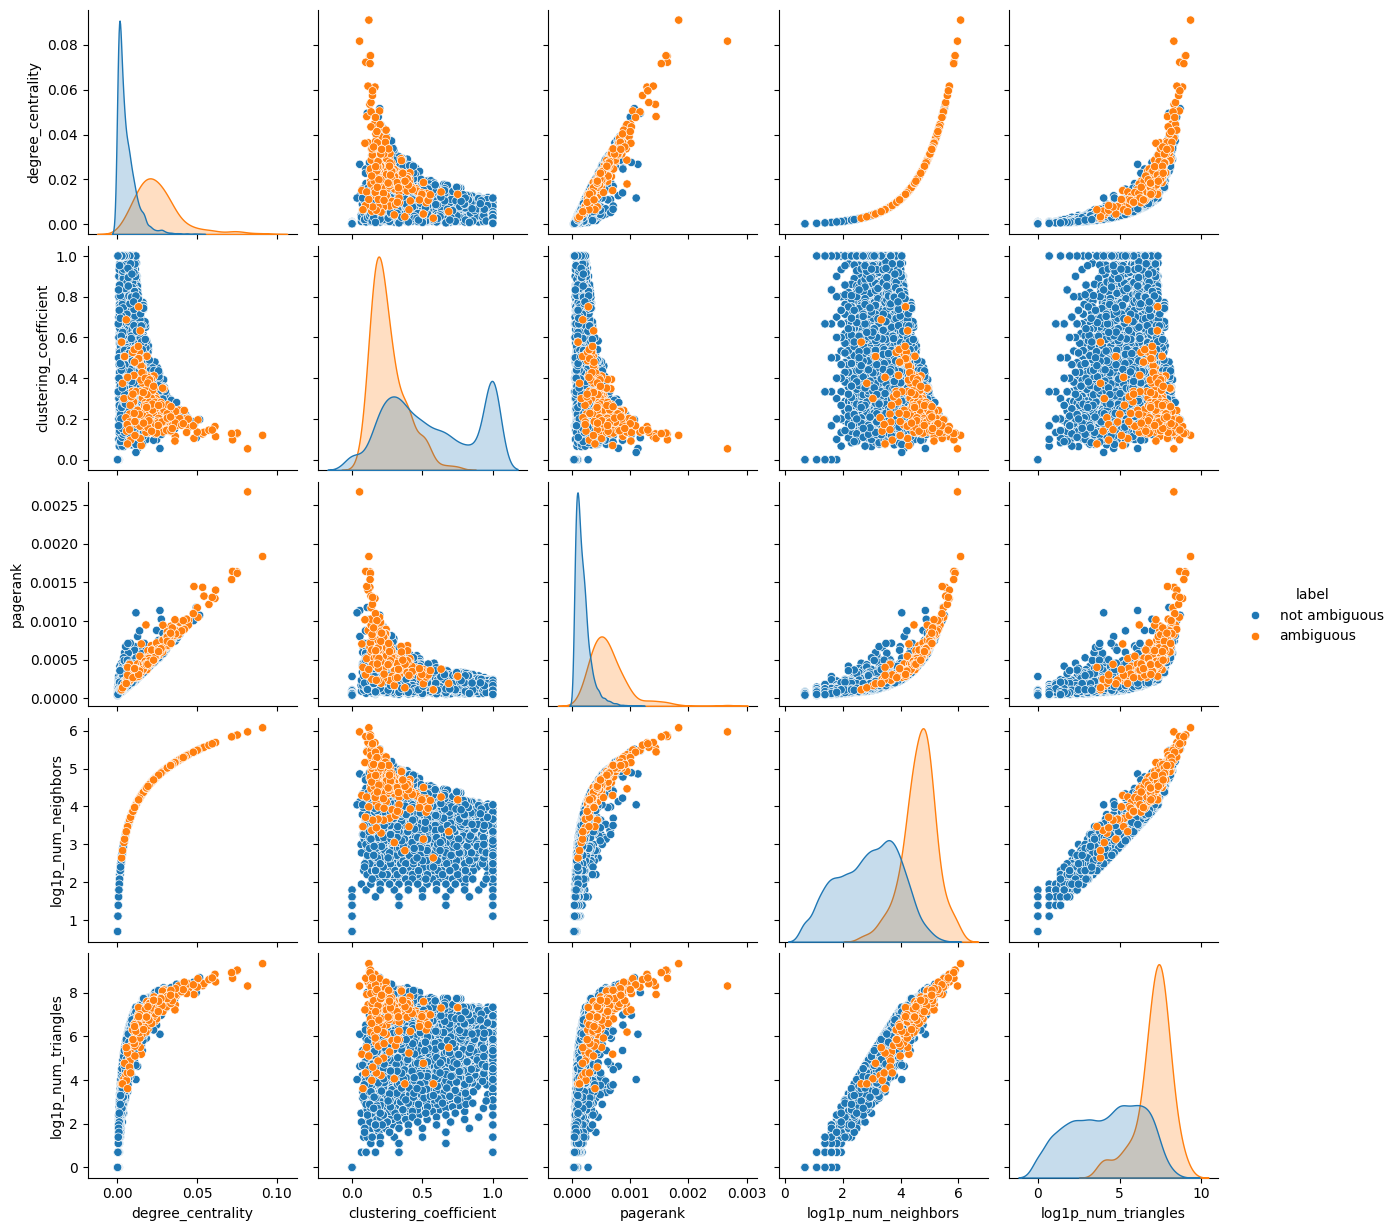

In [30]:
sns.pairplot(
    df_manual_features,
    hue="label",
    diag_kind="kde",
    diag_kws={"common_norm": False},
)

**Practical Activity:** Compute PCA of the manual features, without reducing the number of features. Visualize the results using pairplot.

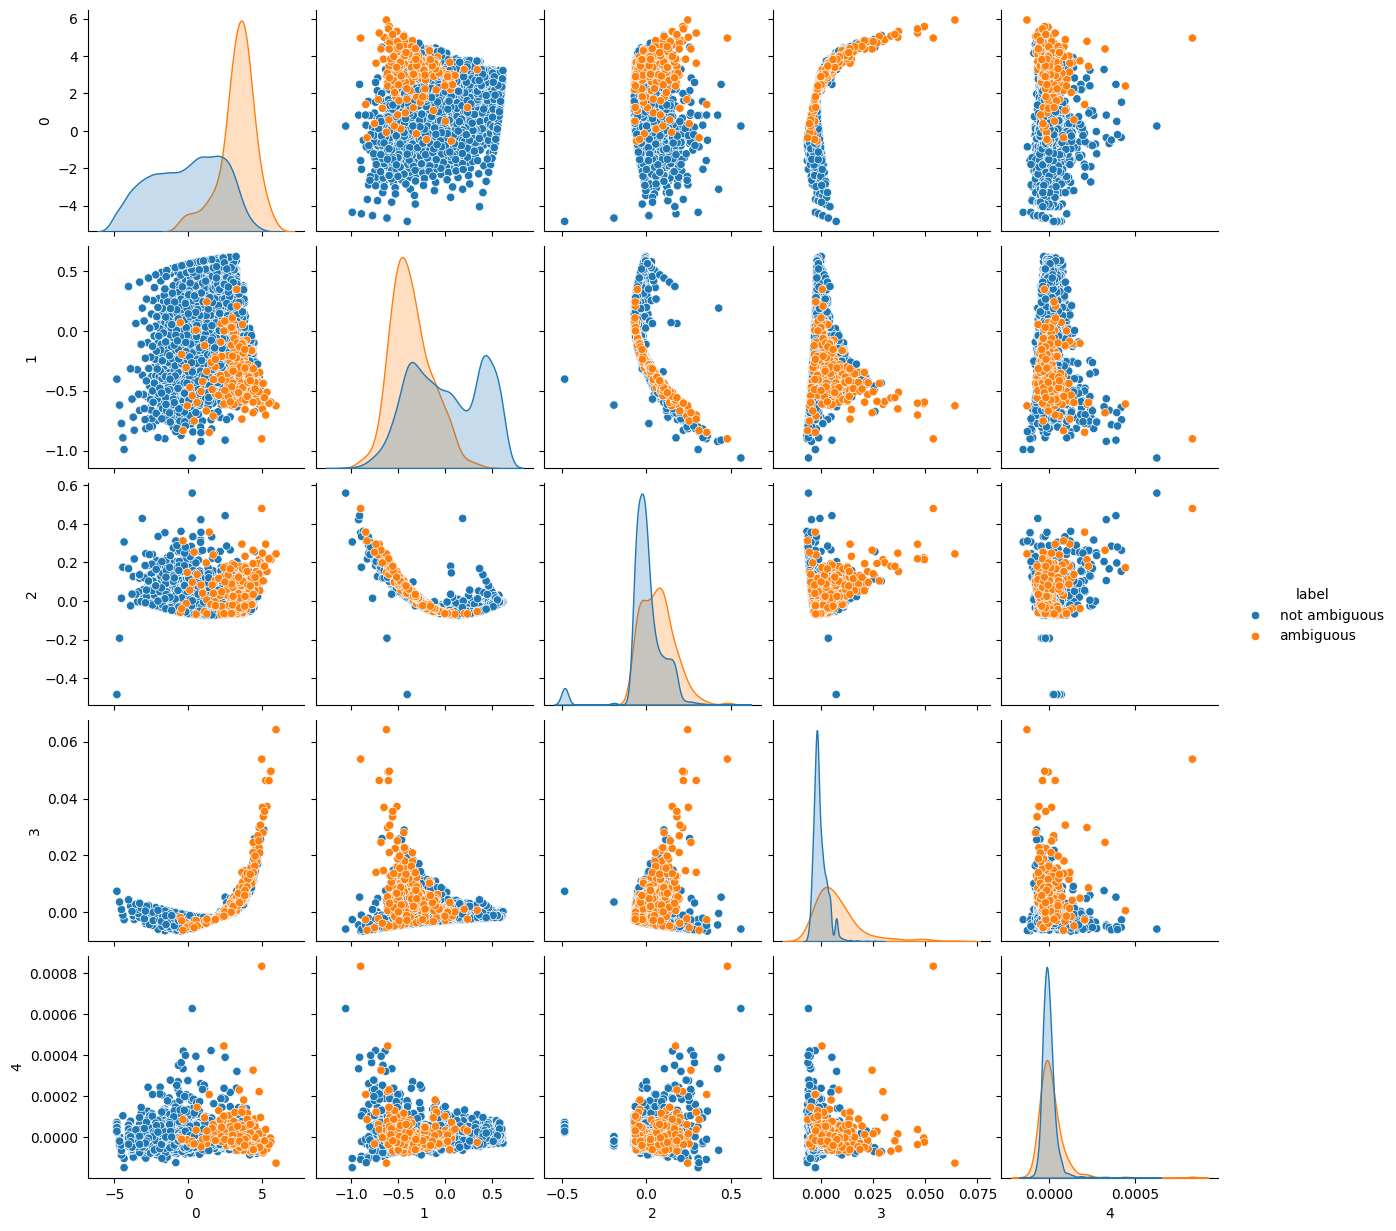

In [31]:
# Visualize manual features using PCA (with two features, PCA is trivial).
pca_manual = PCA(n_components=df_manual_features.shape[1]-1)
df_manual_features_pca = pd.DataFrame(pca_manual.fit_transform(df_manual_features.drop(columns=['label'])))
df_manual_features_pca["label"] = df_graph_data["label"].values
sns.pairplot(
    df_manual_features_pca,
    hue="label",
    diag_kind="kde",
    diag_kws={"common_norm": False},
)

### Observations & Explanations

What can you say about the pair graphs of the manual features vs its PCA?

### Practical Activities
- **Activity 1:** Generate a set of node embeddings using Node2Vec on the Astro Physics network and visualize them using PCA.  
- **Activity 2:** Compute different graph metrics (e.g., betweenness centrality) and visualize these features. Experiment by combining them with the embeddings to observe changes in the representation.


### Graph Label Propagation

## Two Approaches

**Direct Graph LP (NetworkX-based):**
- Uses explicit graph structure and topology
- Nodes connected by actual edges in the network
- Labels propagate through real relationships (social connections, citations, etc.)
- Perfect for: social networks, citation graphs, biological networks

**Indirect Graph LP (Scikit-learn):**
- Constructs similarity graph from feature vectors
- Nodes connected based on feature similarity (k-NN, RBF kernels)
- Labels propagate through feature space proximity
- Perfect for: tabular data, high-dimensional features

## The Algorithm (Both Types)

1. **Initialize**: Build/use graph structure, set labeled nodes
2. **Propagate**: Labeled nodes keep their labels
3. **Update**: Unlabeled nodes iteratively update based on neighbors
4. **Converge**: Process continues until labels stabilize


Graph info:
Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Edges: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (5, 6), (5, 7), (6, 7), (6, 8), (7, 8), (8, 9)]
Labeled nodes: {0: 'A', 1: 'A', 7: 'B', 8: 'B'}


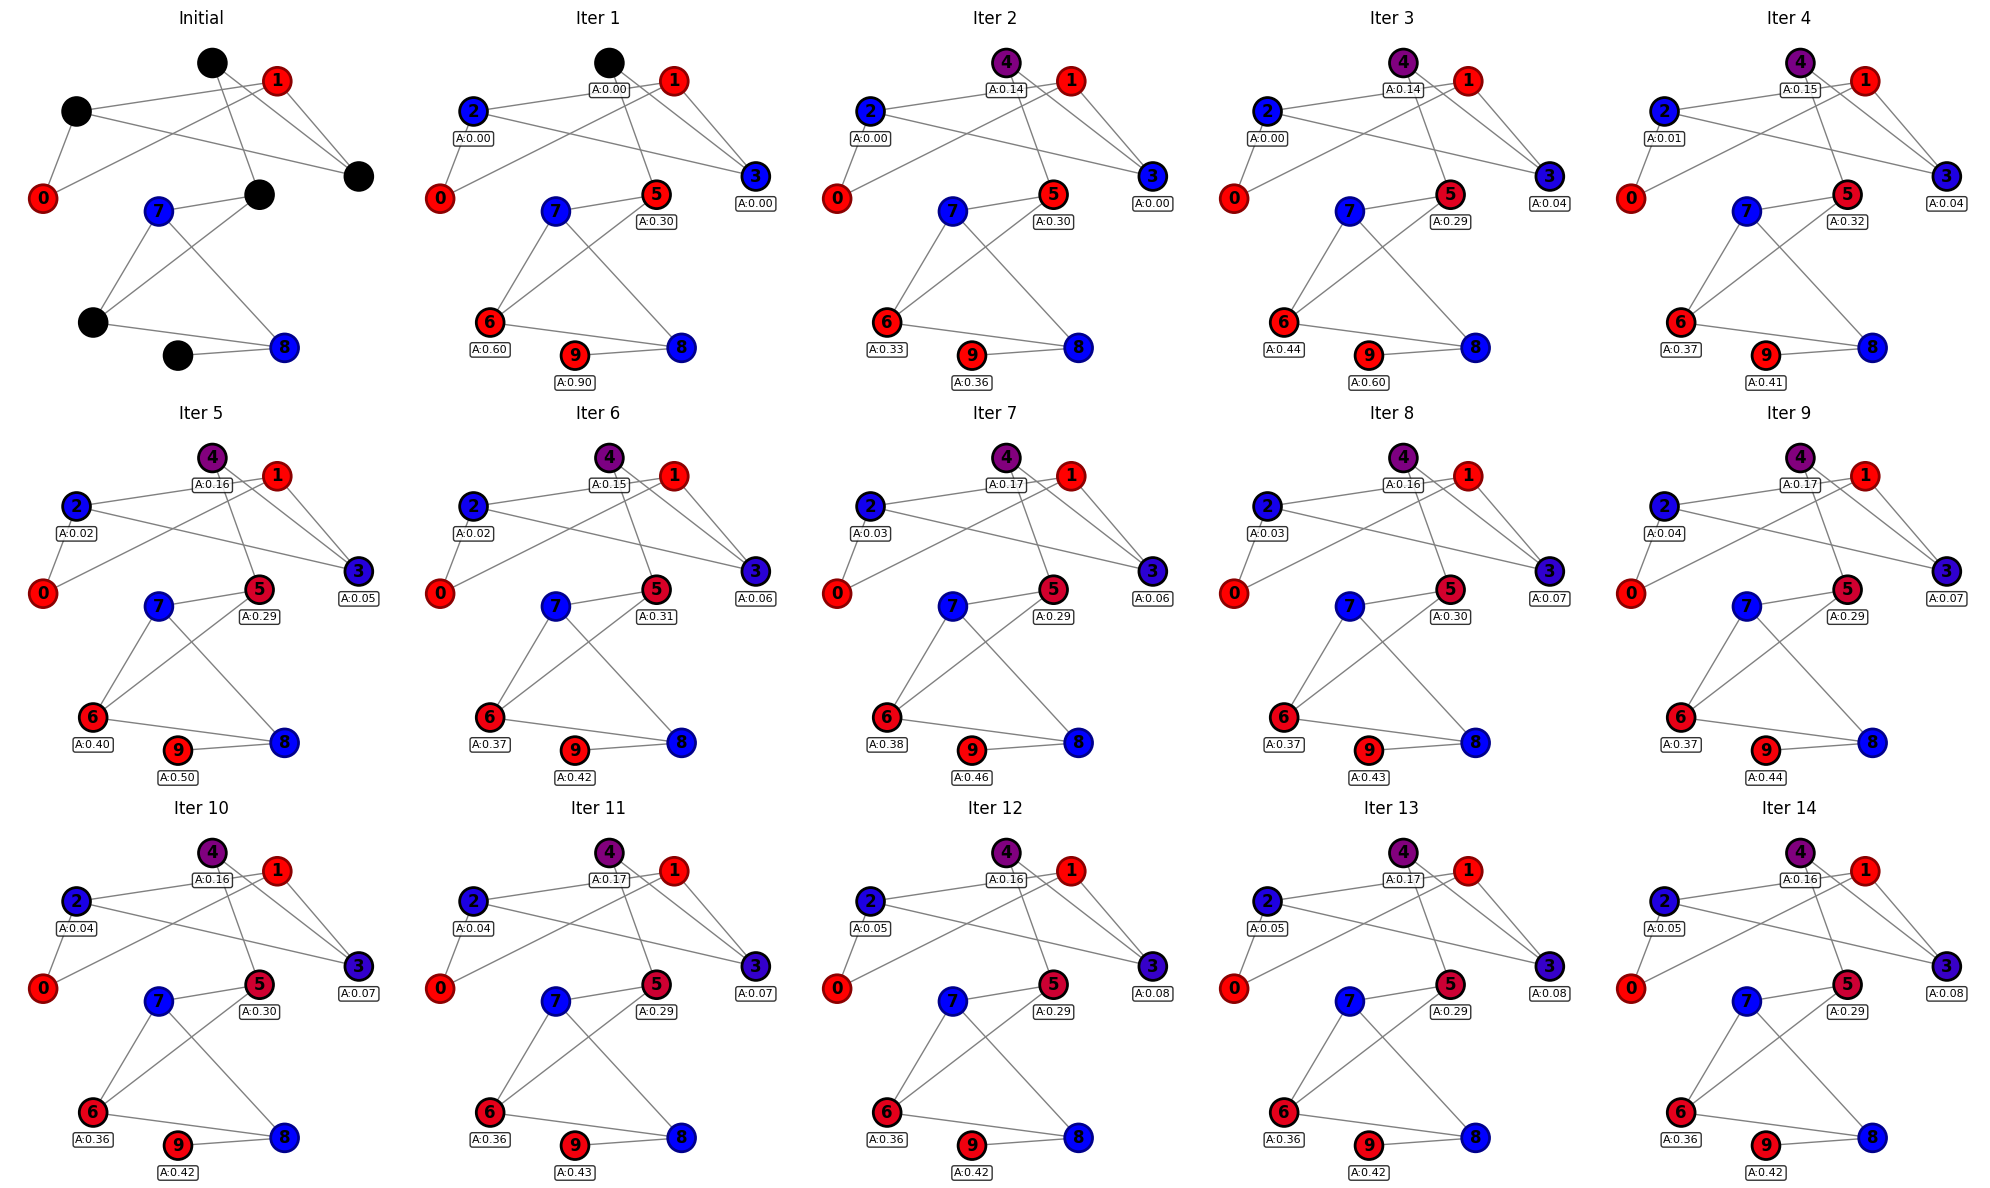


Final predicted labels:
Node 0: A -> A
Node 1: A -> A
Node 2: unlabeled -> A
Node 3: unlabeled -> A
Node 4: unlabeled -> B
Node 5: unlabeled -> B
Node 6: unlabeled -> B
Node 7: B -> B
Node 8: B -> B
Node 9: unlabeled -> B


In [32]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def direct_label_propagation(G, labeled_nodes, max_iterations=100, alpha=0.9):
    """
    Direct label propagation on a NetworkX graph.

    Parameters:
    - G: NetworkX graph
    - labeled_nodes: dict {node_id: label} for initially labeled nodes
    - max_iterations: maximum number of iterations
    - alpha: damping factor (0.9 means 90% from neighbors, 10% from original)
    """

    # Initialize label probabilities for each node
    nodes = list(G.nodes())
    labels = list(set(labeled_nodes.values()))
    n_nodes = len(nodes)
    n_labels = len(labels)

    # Create label-to-index mapping
    label_to_idx = {label: i for i, label in enumerate(labels)}

    # Initialize probability matrix: [n_nodes, n_labels]
    Y = np.zeros((n_nodes, n_labels))
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Set initial labeled nodes to 1.0 probability for their class
    for node, label in labeled_nodes.items():
        node_idx = node_to_idx[node]
        label_idx = label_to_idx[label]
        Y[node_idx, label_idx] = 1.0

    # Create transition matrix (normalized adjacency matrix)
    A = nx.adjacency_matrix(G, nodelist=nodes).astype(float)
    # Normalize rows (each row sums to 1)
    row_sums = np.array(A.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1  # Avoid division by zero for isolated nodes
    D_inv = np.diag(1.0 / row_sums)
    T = D_inv @ A  # Transition matrix

    # Store original labeled node values
    Y_original = Y.copy()

    print(f"Starting label propagation...")
    print(f"Nodes: {n_nodes}, Labels: {labels}")
    print(f"Initially labeled: {len(labeled_nodes)} nodes")

    # Iterative label propagation
    for iteration in range(max_iterations):
        Y_prev = Y.copy()

        # Update: Y = alpha * T @ Y + (1-alpha) * Y_original
        Y = alpha * (T @ Y) + (1 - alpha) * Y_original

        # Check convergence
        diff = np.abs(Y - Y_prev).max()
        if diff < 1e-6:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Get final predictions
    predicted_labels = {}
    for i, node in enumerate(nodes):
        best_label_idx = np.argmax(Y[i])
        predicted_labels[node] = labels[best_label_idx]

    return predicted_labels, Y

def visualize_label_propagation(G, labeled_nodes, predicted_labels):
    """Visualize the graph with original and predicted labels."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    pos = nx.spring_layout(G, random_state=42)

    # Colors for different labels
    label_colors = {'A': 'red', 'B': 'blue', 'unlabeled': 'lightgray'}

    # Plot 1: Original (only labeled nodes colored)
    node_colors1 = []
    for node in G.nodes():
        if node in labeled_nodes:
            node_colors1.append(label_colors[labeled_nodes[node]])
        else:
            node_colors1.append(label_colors['unlabeled'])

    nx.draw(G, pos, node_color=node_colors1, with_labels=True,
            node_size=300, ax=ax1, edge_color='gray')
    ax1.set_title("Original: Only Some Nodes Labeled")

    # Plot 2: After label propagation
    node_colors2 = [label_colors[predicted_labels[node]] for node in G.nodes()]
    nx.draw(G, pos, node_color=node_colors2, with_labels=True,
            node_size=300, ax=ax2, edge_color='gray')
    ax2.set_title("After Label Propagation: All Nodes Labeled")

    plt.tight_layout()
    plt.show()

# Example: Create a small graph and demonstrate label propagation
def demo_direct_label_propagation():
    """Demonstrate direct label propagation on a simple graph with iteration visualization."""

    # Create a graph with two communities
    G = nx.Graph()

    # Community 1 (nodes 0-4)
    G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])

    # Community 2 (nodes 5-9)
    G.add_edges_from([(5, 6), (5, 7), (6, 7), (6, 8), (7, 8), (8, 9)])

    # Bridge between communities
    G.add_edge(4, 5)

    # Compute fixed layout for consistent visualization
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Label only a few nodes
    labeled_nodes = {
        0: 'A',  # Community 1
        1: 'A',  # Community 1
        7: 'B',  # Community 2
        8: 'B'   # Community 2
    }

    print("Graph info:")
    print(f"Nodes: {list(G.nodes())}")
    print(f"Edges: {list(G.edges())}")
    print(f"Labeled nodes: {labeled_nodes}")

    # Modified label propagation with iteration tracking
    predicted_labels, probabilities, iteration_history = direct_label_propagation_with_history(
        G, labeled_nodes, pos
    )

    print(f"\nFinal predicted labels:")
    for node in sorted(G.nodes()):
        original = labeled_nodes.get(node, 'unlabeled')
        predicted = predicted_labels[node]
        print(f"Node {node}: {original} -> {predicted}")

    return G, labeled_nodes, predicted_labels

def direct_label_propagation_with_history(G, labeled_nodes, pos, max_iterations=14, alpha=0.9):
    """
    Label propagation with visualization at each iteration.
    """

    # Initialize (same as before)
    nodes = list(G.nodes())
    labels = list(set(labeled_nodes.values()))
    n_nodes = len(nodes)
    n_labels = len(labels)

    label_to_idx = {label: i for i, label in enumerate(labels)}
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    Y = np.zeros((n_nodes, n_labels))
    for node, label in labeled_nodes.items():
        node_idx = node_to_idx[node]
        label_idx = label_to_idx[label]
        Y[node_idx, label_idx] = 1.0

    # Create transition matrix
    A = nx.adjacency_matrix(G, nodelist=nodes).astype(float)
    row_sums = np.array(A.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1
    D_inv = np.diag(1.0 / row_sums)
    T = D_inv @ A

    Y_original = Y.copy()

    # Setup visualization
    n_cols = min(5, max_iterations + 1)  # Show max 5 plots per row
    n_rows = (max_iterations + 1 + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    # Plot initial state
    plot_iteration(G, pos, Y, labels, nodes, labeled_nodes, axes[0, 0], "Initial", 0)

    iteration_history = [Y.copy()]

    # Iterative propagation with visualization
    for iteration in range(max_iterations):
        Y_prev = Y.copy()
        Y = alpha * (T @ Y) + (1 - alpha) * Y_original
        iteration_history.append(Y.copy())

        # Plot current iteration
        row = (iteration + 1) // n_cols
        col = (iteration + 1) % n_cols
        if row < n_rows and col < n_cols:
            plot_iteration(G, pos, Y, labels, nodes, labeled_nodes,
                         axes[row, col], f"Iter {iteration + 1}", iteration + 1)

        # Check convergence
        diff = np.abs(Y - Y_prev).max()
        if diff < 1e-6:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Hide unused subplots
    for row in range(n_rows):
        for col in range(n_cols):
            if row * n_cols + col > iteration + 1:
                axes[row, col].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Get final predictions
    predicted_labels = {}
    for i, node in enumerate(nodes):
        best_label_idx = np.argmax(Y[i])
        predicted_labels[node] = labels[best_label_idx]

    return predicted_labels, Y, iteration_history

def plot_iteration(G, pos, Y, labels, nodes, labeled_nodes, ax, title, iteration):
    """Plot graph state at a specific iteration."""

    # Create node colors based on current probabilities
    node_colors = []
    edge_colors = []

    for i, node in enumerate(nodes):
        if node in labeled_nodes:
            # Originally labeled nodes: use solid color
            if labeled_nodes[node] == 'A':
                node_colors.append('red')
                edge_colors.append('darkred')
            else:
                node_colors.append('blue')
                edge_colors.append('darkblue')
        else:
            # Unlabeled nodes: color by probability
            prob_A = Y[i, 0]  # Probability of label A
            prob_B = Y[i, 1]  # Probability of label B

            # Mix red and blue based on probabilities
            red_component = prob_A
            blue_component = prob_B
            # Normalize to avoid oversaturation
            total = red_component + blue_component
            if total > 0:
                red_component /= total
                blue_component /= total

            color = (red_component, 0, blue_component)
            node_colors.append(color)
            edge_colors.append('black')

    # Draw graph
    nx.draw(G, pos, node_color=node_colors, edgecolors=edge_colors,
            with_labels=True, node_size=400, ax=ax, edge_color='gray',
            linewidths=2, font_weight='bold')

    ax.set_title(title)

    # Add probability text for unlabeled nodes
    if iteration > 0:
        for i, node in enumerate(nodes):
            if node not in labeled_nodes:
                x, y = pos[node]
                prob_A = Y[i, 0]
                ax.text(x, y-0.15, f'A:{prob_A:.2f}', ha='center', va='top',
                       fontsize=8, bbox=dict(boxstyle='round,pad=0.2',
                       facecolor='white', alpha=0.8))

# Run the demonstration
if __name__ == "__main__":
    demo_direct_label_propagation()

**Label Propagation Colors Explained**

**Node Colors:**
- 🔴 **Red**: Originally labeled "A" (fixed throughout)
- 🔵 **Blue**: Originally labeled "B" (fixed throughout)  
- 🟣 **Purple**: Unlabeled nodes with mixed probabilities
- ⚫ **Black**: Unlabeled nodes with no influence yet

**Color Intensity:**
- More red = higher probability of label A
- More blue = higher probability of label B
- Numbers show exact probabilities (e.g., "A:0.60" = 60% label A)

**Process:**
1. **Initial**: Only 4 nodes labeled, rest black
2. **Early iterations**: Labels spread to neighbors, creating purple mixed states
3. **Later iterations**: Probabilities converge, colors become more pure
4. **Bridge nodes**: Connecting different communities stay mixed longest

The visualization shows how labels "flow" through network structure, with community boundaries and bridge effects clearly visible.

In [47]:
# 30 sec
from collections import Counter

# Compute layout positions for consistent visualization
pos = nx.fruchterman_reingold_layout(G)

Label distribution:
  unlabeled (-1): 3353
  not ambiguous (0): 1373
  ambiguous (1): 64


Text(0.5, 1.0, 'Initial: Partial Labels\n(Orange=Ambiguous, Blue=Not Ambiguous, Gray=Unlabeled)')

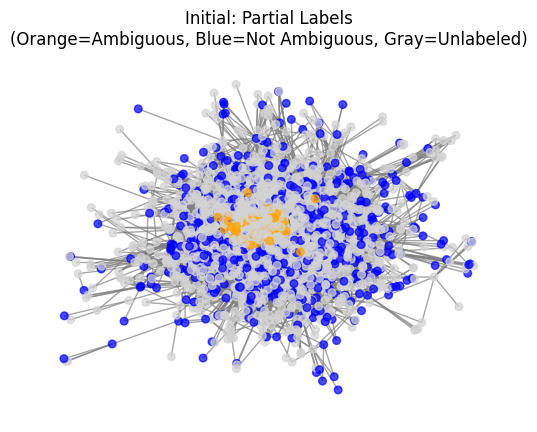

In [48]:
# Add numeric labels: 1 for "ambiguous", 0 for "not ambiguous", -1 for unlabeled
np.random.seed(42)
all_nodes = list(G.nodes())
# Get original labels
original_labels = nx.get_node_attributes(G, "label")

# Create label_numeric attribute
for node in all_nodes:
    if original_labels[node] == "ambiguous":
        G.nodes[node]["label_numeric"] = 1
    else:  # 'not ambiguous'
        G.nodes[node]["label_numeric"] = 0

# Randomly select 70% of nodes to unlabel (set to -1)
n_to_unlabel = int(0.7 * len(all_nodes))
nodes_to_unlabel = np.random.choice(all_nodes, size=n_to_unlabel, replace=False)

for node in nodes_to_unlabel:
    G.nodes[node]["label_numeric"] = -1

# Get label_numeric values for visualization
label_numeric = nx.get_node_attributes(G, "label_numeric")

print(f"Label distribution:")
label_counts = Counter(label_numeric.values())
for label, count in label_counts.items():
    label_name = {1: "ambiguous", 0: "not ambiguous", -1: "unlabeled"}[label]
    print(f"  {label_name} ({label}): {count}")


# Create color mapping for managua colormap
def get_node_colors(label_dict):
    colors = []
    for node in G.nodes():
        label = label_dict[node]
        if label == 1:  # ambiguous
            colors.append("orange")
        elif label == 0:  # not ambiguous
            colors.append("blue")
        else:  # unlabeled (-1)
            colors.append("lightgray")
    return colors


# Visualize initial state
fig, ax = plt.subplots()

# Plot 1: Initial state with partial labels
node_colors_initial = get_node_colors(label_numeric)
nx.draw(
    G,
    pos,
    node_color=node_colors_initial,
    node_size=30,
    edge_color="gray",
    alpha=0.7,
    ax=ax,
)
ax.set_title(
    "Initial: Partial Labels\n(Orange=Ambiguous, Blue=Not Ambiguous, Gray=Unlabeled)"
)


In [56]:
current_labels = nx.get_node_attributes(G, "label_numeric").copy()
from networkx.algorithms.community import label_propagation_communities

labels_propagated = label_propagation_communities(G)
labels_propagated

dict_values([{'97916', '9486', '59292', '67774', '102371', '88348', '10804', '76400', '124591', '69499', '28128', '58919', '69525_6443', '91787', '13440', '17', '9205', '11165', '117811', '45451', '87038', '128016', '102950', '37861', '44011', '114281', '31565', '5638', '79360', '10199', '18396', '15161', '51146', '122128', '63141', '131866', '35930', '71854', '2760_125226', '66356', '108418', '80600', '52907', '123142', '60390', '79467', '106126', '52703', '110535', '64261', '76952', '50148', '117394_31334', '99370', '72173', '42793', '84506', '59647', '50687', '19898', '72201', '88115', '18941', '80408', '101994', '119462', '126152', '77425', '65191', '113555', '117627', '20775', '1949_94624', '75132', '121002', '121052', '109770', '50124_10914', '97906', '92276', '42551', '69582', '44333', '83653_59069', '40855', '16123', '122485', '125892', '86842', '19926', '45194', '35152', '35596', '118779', '8094', '25850', '94376', '128985', '99466', '97012', '46415', '122568', '20733_14859', 

In [49]:
# Run simple label propagation
def simple_label_propagation(G, max_iterations=20):
    """Simple label propagation that respects existing labels."""

    current_labels = nx.get_node_attributes(G, "label_numeric").copy()

    for iteration in range(max_iterations):
        new_labels = current_labels.copy()
        updated_count = 0

        for node in G.nodes():
            if current_labels[node] != -1:  # Skip already labeled nodes
                continue

            # Get labeled neighbors
            neighbor_labels = []
            for neighbor in G.neighbors(node):
                if current_labels[neighbor] != -1:
                    neighbor_labels.append(current_labels[neighbor])

            # Assign most common neighbor label
            if neighbor_labels:
                most_common = Counter(neighbor_labels).most_common(1)[0][0]
                new_labels[node] = most_common
                updated_count += 1

        print(f"Iteration {iteration + 1}: {updated_count} nodes labeled")

        if updated_count == 0:
            print(f"Converged after {iteration + 1} iterations")
            break

        current_labels = new_labels

    return current_labels


# Run label propagation
print("\nRunning label propagation...")
propagated_labels = simple_label_propagation(G)

# Show final distribution
print(f"\nFinal label distribution:")
final_counts = Counter(propagated_labels.values())
for label, count in final_counts.items():
    label_name = {1: "ambiguous", 0: "not ambiguous", -1: "unlabeled"}[label]
    print(f"  {label_name} ({label}): {count}")



Running label propagation...
Iteration 1: 3079 nodes labeled
Iteration 2: 272 nodes labeled
Iteration 3: 2 nodes labeled
Iteration 4: 0 nodes labeled
Converged after 4 iterations

Final label distribution:
  not ambiguous (0): 4637
  ambiguous (1): 153


In [51]:
[(n, d) for n, d in G.nodes(data=True)]

[('65541', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('13', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('17', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('131091', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('26', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('98346', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('131122', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('98356', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('57', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('73', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('65610', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('80', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('65620', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('86', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('131167', {'label': 'not ambiguous', 'label_numeric': -1}),
 ('65642', {'label': 'not ambiguous', 'label_numeric': 0}),
 ('106', {'label': 'not ambiguous', 'label_numeri

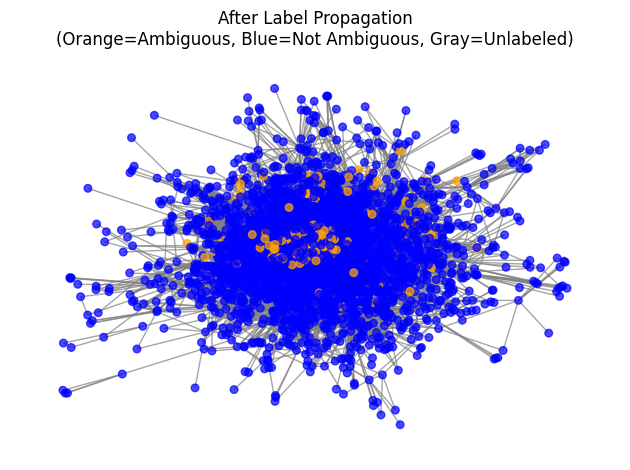

In [50]:
# Plot 2: After label propagation
fig, ax = plt.subplots()
node_colors_final = get_node_colors(propagated_labels)
nx.draw(
    G,
    pos,
    node_color=node_colors_final,
    node_size=30,
    edge_color="gray",
    alpha=0.7,
    ax=ax,
)
ax.set_title(
    "After Label Propagation\n(Orange=Ambiguous, Blue=Not Ambiguous, Gray=Unlabeled)"
)

plt.tight_layout()
plt.show()

In [ ]:


# Calculate accuracy on nodes that were originally unlabeled
original_numeric = nx.get_node_attributes(G, "label_numeric")
evaluation_nodes = [node for node in G.nodes() if original_numeric[node] == -1]

if evaluation_nodes:
    y_true = [
        1 if original_labels[node] == "ambiguous" else 0 for node in evaluation_nodes
    ]
    y_pred = [
        propagated_labels[node]
        for node in evaluation_nodes
        if propagated_labels[node] != -1
    ]
    y_true_evaluated = [
        1 if original_labels[node] == "ambiguous" else 0
        for node in evaluation_nodes
        if propagated_labels[node] != -1
    ]

    if y_pred:
        from sklearn.metrics import accuracy_score, f1_score

        accuracy = accuracy_score(y_true_evaluated, y_pred)
        f1 = f1_score(y_true_evaluated, y_pred, zero_division=0)
        print(f"\nEvaluation on originally unlabeled nodes:")
        print(f"  Nodes evaluated: {len(y_pred)} / {len(evaluation_nodes)}")
        print(f"  Accuracy: {accuracy:.3f}")
        print(f"  F1 Score: {f1:.3f}")
    else:
        print("\nNo predictions made for evaluation")

In [36]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    balanced_accuracy_score,
)


def run_manual_semi_supervised_lp(G, ratio=0.3, random_state=42, max_iterations=50):
    """
    Manual semi-supervised label propagation that actually uses existing labels as seeds.
    """

    np.random.seed(random_state)

    # Get all true labels
    all_labels = nx.get_node_attributes(G, "label")
    nodes = list(all_labels.keys())

    # Stratified sampling to keep some nodes labeled
    labeled_nodes = []
    unlabeled_nodes = []

    for label in np.unique(list(all_labels.values())):
        label_nodes = [n for n in nodes if all_labels[n] == label]
        n_to_keep = max(1, int(len(label_nodes) * ratio))

        labeled_selected = np.random.choice(label_nodes, size=n_to_keep, replace=False)
        unlabeled_selected = [n for n in label_nodes if n not in labeled_selected]

        labeled_nodes.extend(labeled_selected)
        unlabeled_nodes.extend(unlabeled_selected)

    # Initialize current labels: only labeled nodes have labels, others are None
    current_labels = {}
    for node in labeled_nodes:
        current_labels[node] = all_labels[node]

    print(
        f"Manual LP: {len(labeled_nodes)} seed nodes, {len(unlabeled_nodes)} to propagate"
    )

    # Iterative label propagation
    for iteration in range(max_iterations):
        new_labels = current_labels.copy()
        updated_count = 0

        # Try to assign labels to unlabeled nodes
        for node in unlabeled_nodes:
            if node in current_labels:  # Already labeled
                continue

            # Get neighbor labels
            neighbor_labels = []
            for neighbor in G.neighbors(node):
                if neighbor in current_labels:
                    neighbor_labels.append(current_labels[neighbor])

            # Assign most common neighbor label
            if neighbor_labels:
                most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
                new_labels[node] = most_common_label
                updated_count += 1

        print(f"  Iteration {iteration + 1}: {updated_count} new labels assigned")

        if updated_count == 0:  # No new labels assigned
            print(f"  Converged after {iteration + 1} iterations")
            break

        current_labels = new_labels

    # Extract predictions for evaluation (unlabeled nodes only)
    y_true = []
    y_pred = []

    for node in unlabeled_nodes:
        if node in current_labels:
            y_true.append(all_labels[node])
            y_pred.append(current_labels[node])

    if not y_true:
        return pd.Series({"error": "No predictions made"})

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"Evaluated {len(y_true)} nodes")
    print(f"True labels: {np.unique(y_true, return_counts=True)}")
    print(f"Predicted labels: {np.unique(y_pred, return_counts=True)}")

    # Convert to numeric for some metrics
    unique_labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_num = {label: i for i, label in enumerate(unique_labels)}
    y_true_num = np.array([label_to_num[label] for label in y_true])
    y_pred_num = np.array([label_to_num[label] for label in y_pred])

    # Calculate metrics
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred, pos_label="ambiguous", zero_division=0),
        "precision": precision_score(
            y_true, y_pred, pos_label="ambiguous", zero_division=0
        ),
        "recall": recall_score(y_true, y_pred, pos_label="ambiguous", zero_division=0),
        "matthews_corrcoef": matthews_corrcoef(y_true_num, y_pred_num),
        "roc_auc": (
            roc_auc_score(y_true_num, y_pred_num)
            if len(np.unique(y_true_num)) > 1
            else np.nan
        ),
        "labeled_ratio": ratio,
        "n_labeled": len(labeled_nodes),
        "n_unlabeled": len(unlabeled_nodes),
        "n_evaluated": len(y_true),
        "true_ambiguous": np.sum(y_true == "ambiguous"),
        "pred_ambiguous": np.sum(y_pred == "ambiguous"),
        "coverage": len(y_true)
        / len(unlabeled_nodes),  # Fraction of unlabeled nodes that got predictions
    }

    return pd.Series(metrics, name=f"Manual_LP_ratio_{ratio}")


# Example usage:
# metrics = run_manual_semi_supervised_lp(G, ratio=0.3)
# print(metrics)

In [38]:
metrics_direct = run_manual_semi_supervised_lp(G, ratio=0.3)
metrics_direct
# %%

Manual LP: 1436 seed nodes, 3354 to propagate
  Iteration 1: 3034 new labels assigned
  Iteration 2: 320 new labels assigned
  Iteration 3: 0 new labels assigned
  Converged after 3 iterations
Evaluated 3354 nodes
True labels: (array(['ambiguous', 'not ambiguous'], dtype='<U13'), array([ 141, 3213]))
Predicted labels: (array(['ambiguous', 'not ambiguous'], dtype='<U13'), array([  62, 3292]))


accuracy                0.939475
balanced_accuracy       0.490352
f1_score                0.000000
precision               0.000000
recall                  0.000000
matthews_corrcoef      -0.028749
roc_auc                 0.490352
labeled_ratio           0.300000
n_labeled            1436.000000
n_unlabeled          3354.000000
n_evaluated          3354.000000
true_ambiguous        141.000000
pred_ambiguous         62.000000
coverage                1.000000
Name: Manual_LP_ratio_0.3, dtype: float64

In [35]:
assert 0

AssertionError: 

In [55]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    balanced_accuracy_score,
)
import numpy as np
import pandas as pd


def run_label_propagation_with_label_ratio(df_in, ratio=0.3, random_state=42):
    """Run label propagation with stratified sampling for labeled/unlabeled split."""
    df_X = df_in.drop(columns=["label"])
    true_labels = df_in["label"].values

    label_encoder = LabelEncoder()
    true_labels_numeric = label_encoder.fit_transform(true_labels)

    # Use stratified sampling to maintain class distribution in labeled set
    sss = StratifiedShuffleSplit(
        n_splits=1, train_size=ratio, random_state=random_state
    )
    labeled_idx, unlabeled_idx = next(sss.split(df_X, true_labels_numeric))

    labels_for_training = np.full(len(true_labels_numeric), -1)
    labels_for_training[labeled_idx] = true_labels_numeric[labeled_idx]

    # Fit label propagation
    label_prop_model = LabelPropagation(kernel="knn", n_neighbors=7)
    label_prop_model.fit(df_X, labels_for_training)
    predicted_labels_numeric = label_prop_model.transduction_

    # Evaluate on unlabeled nodes (transductive evaluation)
    y_true_unlabeled = true_labels_numeric[unlabeled_idx]
    y_pred_unlabeled = predicted_labels_numeric[unlabeled_idx]

    # Calculate metrics on unlabeled set (proper semi-supervised evaluation)
    pos_label_idx = np.where(label_encoder.classes_ == "ambiguous")[0][0]

    metrics = {
        "accuracy": accuracy_score(y_true_unlabeled, y_pred_unlabeled),
        "balanced_accuracy": balanced_accuracy_score(
            y_true_unlabeled, y_pred_unlabeled
        ),
        "precision": precision_score(
            y_true_unlabeled, y_pred_unlabeled, pos_label=pos_label_idx
        ),
        "recall": recall_score(
            y_true_unlabeled, y_pred_unlabeled, pos_label=pos_label_idx
        ),
        "f1_score": f1_score(
            y_true_unlabeled, y_pred_unlabeled, pos_label=pos_label_idx
        ),
        "matthews_corrcoef": matthews_corrcoef(y_true_unlabeled, y_pred_unlabeled),
        "roc_auc": (
            roc_auc_score(y_true_unlabeled, y_pred_unlabeled)
            if len(np.unique(y_true_unlabeled)) > 1
            else np.nan
        ),
        "labeled_ratio": ratio,
        "n_labeled": len(labeled_idx),
        "n_unlabeled": len(unlabeled_idx),
        "n_total": len(true_labels),
    }

    return pd.Series(metrics, name=f"LP_ratio_{ratio}")

In [56]:
df_node2vec_features['label'] = df_graph_data['label'].values

In [ ]:
df_performances = pd.DataFrame(
    {
        'manual': run_label_propagation_with_label_ratio(df_manual_features, ratio=0.3),
        'node2vec': run_label_propagation_with_label_ratio(df_node2vec_features, ratio=0.3),
        'manual pca': run_label_propagation_with_label_ratio(df_manual_features_pca, ratio=0.3),
        'node2vec pca': run_label_propagation_with_label_ratio(df_node2vec_features_pca, ratio=0.3),
    }
).T

df_performances

# %%

Look at the high "accuracy" values and the low values of ROC AUC, matthews_corrcoef, and balanced_accuracy_score.

## Section 4: Case Studies – Application in Citation Networks and Fraud Detection


### Objectives
- Explore real-world applications of supervised learning on graph data.
- Analyze case studies using the Astro Physics collaboration network as a proxy for citation networks and simulate a fraud detection scenario.


### Introduction
In this section, we present two case studies:
1. **Citation Network Analysis:** Although the Astro Physics dataset represents collaborations, we use it to simulate a simplified citation network analysis by examining centrality and clustering measures.
2. **Fraud Detection Simulation:** We create synthetic labels to simulate fraud detection by designating nodes with exceptionally high degrees as fraudulent. A classifier is then trained on graph-based features, and performance is evaluated using a confusion matrix and ROC curve.


### Key Points
- **Citation Network Analysis:**
  - Compute average degree centrality and clustering coefficient.
  - Visualize the degree distribution to understand network connectivity.
- **Fraud Detection Simulation:**
  - Generate synthetic fraud labels based on a threshold (e.g., nodes with degree > mean + standard deviation are labeled as fraudulent).
  - Create a feature matrix using graph metrics (degree centrality and clustering coefficient).
  - Train a logistic regression classifier and evaluate performance with confusion matrix and ROC curve.


### Code Examples
Below is the code that implements the two case studies using the Astro Physics collaboration network.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# Load the Astro Physics collaboration network as an undirected graph.
G = nx.read_edgelist(
    "ca-AstroPh.txt", create_using=nx.Graph(), nodetype=int, comments="#"
)
print("Graph Loaded: Nodes =", G.number_of_nodes(), "Edges =", G.number_of_edges())

# ----- Case Study 1: Simplified Citation Network Analysis -----
# Compute degree centrality and clustering coefficient
deg_cent = nx.degree_centrality(G)
avg_deg_cent = np.mean(list(deg_cent.values()))
avg_clust = nx.average_clustering(G)
print("Average Degree Centrality:", avg_deg_cent)
print("Average Clustering Coefficient:", avg_clust)

# Visualize degree distribution
degrees = [G.degree(n) for n in G.nodes()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50, color="skyblue", edgecolor="black")
plt.title("Degree Distribution of Astro Physics Collaboration Network")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# ----- Case Study 2: Fraud Detection Simulation -----
# Simulate fraud: label nodes as fraudulent (1) if degree > (mean + std), else non-fraud (0)
degrees_array = np.array(degrees)
mean_deg = degrees_array.mean()
std_deg = degrees_array.std()
fraud_threshold = mean_deg + std_deg
labels = np.array([1 if deg > fraud_threshold else 0 for deg in degrees])
print("Number of fraudulent nodes (simulated):", sum(labels))

# Create a feature matrix using degree centrality and clustering coefficient for each node.
nodes = list(G.nodes())
features = np.array([[deg_cent[node], nx.clustering(G, node)] for node in nodes])

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.3, random_state=42
)

# Train a Logistic Regression classifier.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Compute confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Compute ROC curve and AUC.
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

# Plot ROC curve.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fraud Detection Simulation")
plt.legend(loc="lower right")
plt.show()

### Observations & Explanations
- **Citation Network Analysis:**  
  The average degree centrality and clustering coefficient provide insights into the overall connectivity and cohesion of the network. The degree distribution visualization reveals the presence of hubs and the spread of node connections.
- **Fraud Detection Simulation:**  
  Synthetic fraud labels are generated by marking nodes with degrees above the threshold (mean + standard deviation) as fraudulent. A logistic regression classifier trained on degree centrality and clustering coefficient features is evaluated using a confusion matrix and ROC curve. The ROC AUC indicates the model's ability to distinguish between fraudulent and non-fraudulent nodes.


### Quiz
1. What are the key challenges when applying supervised learning to citation networks?  
2. How does graph-based feature engineering contribute to fraud detection?


### Practical Activities
- **Activity 1:** Modify the fraud detection threshold (e.g., try mean + 0.5*std or mean + 1.5*std) and observe how the number of fraudulent nodes and model performance metrics (accuracy, AUC) change.
- **Activity 2:** Experiment with adding additional graph metrics (e.g., betweenness centrality) to the feature matrix, retrain the classifier, and compare performance using confusion matrix and ROC curve.


## Section 5: Implementation of Supervised Learning Pipelines on Graph Data


### Objectives
- Build a complete supervised learning pipeline for graph data.
- Integrate data preprocessing, feature engineering, model training, and evaluation into one workflow.


### Introduction
In this section, we construct an end-to-end pipeline that uses graph-specific features extracted from the Astro Physics collaboration network. We will compute features such as degree centrality and clustering coefficient, then use these features to train a logistic regression classifier. The pipeline will incorporate data scaling, hyperparameter tuning using cross-validation, and visualization of performance metrics.


### Key Points
- **Pipeline Stages:**  
  - Data preparation: Load the graph and compute graph metrics.
  - Feature extraction: Build a feature matrix from degree centrality and clustering coefficient.
  - Model training: Use a classifier (e.g., Logistic Regression) within a scikit-learn Pipeline.
  - Evaluation: Apply cross-validation and hyperparameter tuning; visualize results with ROC curves.
- **Best Practices:**  
  - Use modular pipeline design for reproducibility.
  - Integrate graph-specific features into traditional machine learning pipelines.


### Code Examples
Below is the code to construct a complete supervised learning pipeline using the Astro Physics dataset. The pipeline includes data preprocessing, feature scaling, model training with Logistic Regression, hyperparameter tuning via GridSearchCV, and performance visualization.


In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.decomposition import PCA

# Load the Astro Physics collaboration network as an undirected graph.
G = nx.read_edgelist(
    "ca-AstroPh.txt", create_using=nx.Graph(), nodetype=int, comments="#"
)
print("Graph Loaded: Nodes =", G.number_of_nodes(), "Edges =", G.number_of_edges())

# For faster execution, use a subgraph of the first 1000 nodes.
subset_nodes = list(G.nodes())[:1000]
G_sub = G.subgraph(subset_nodes).copy()
print("Subgraph: Nodes =", G_sub.number_of_nodes(), "Edges =", G_sub.number_of_edges())

# Compute graph metrics: degree centrality and clustering coefficient.
deg_cent = nx.degree_centrality(G_sub)
clust_coeff = nx.clustering(G_sub)

# Create feature matrix X: each row corresponds to a node with features [degree centrality, clustering coefficient].
nodes = list(G_sub.nodes())
X = np.array([[deg_cent[node], clust_coeff[node]] for node in nodes])

# For demonstration, simulate binary labels:
# Label nodes as '1' if degree centrality is above the median, else '0'.
median_deg = np.median([deg_cent[node] for node in nodes])
y = np.array([1 if deg_cent[node] > median_deg else 0 for node in nodes])
print("Feature matrix shape:", X.shape)
print("Labels distribution:", np.bincount(y))

# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Construct a supervised learning pipeline with scaling and logistic regression.
pipeline = Pipeline(
    [("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]
)

# Set up hyperparameter grid for tuning (e.g., regularization strength C).
param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV for hyperparameter tuning with 5-fold cross-validation.
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate the pipeline on the test set.
y_pred = grid_search.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy:", test_accuracy)

# Compute ROC curve and AUC.
y_prob = grid_search.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("Test ROC AUC:", roc_auc)

# Plot ROC curve.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Supervised Learning Pipeline")
plt.legend(loc="lower right")
plt.show()

# Visualize feature space using PCA.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", s=20, alpha=0.7)
plt.title("PCA of Graph Features (Degree Centrality & Clustering Coefficient)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="True Label")
plt.show()

### Observations & Explanations
- **Pipeline Construction:** The pipeline integrates data scaling and logistic regression, making the process modular and reproducible.
- **Hyperparameter Tuning:** GridSearchCV efficiently tunes the regularization parameter to optimize model performance.
- **Evaluation:** The ROC curve and AUC provide a comprehensive view of the classifier’s performance on the test set.
- **Visualization:** PCA is used to visualize the distribution of graph features, aiding in understanding the separation between classes.


### Quiz
1. What are the main stages of a supervised learning pipeline for graph data?  
2. How can cross-validation be effectively applied in graph-based supervised learning?


### Practical Activities
- **Activity 1:** Modify the hyperparameter grid (e.g., try additional values for `C`) and observe how the best parameters and test accuracy change.
- **Activity 2:** Experiment with adding additional graph features (such as betweenness centrality) to the feature matrix and evaluate the impact on model performance.


### Explanation/Feedback
The code above demonstrates an end-to-end supervised learning pipeline using graph features derived from the Astro Physics collaboration network. By combining data scaling, hyperparameter tuning, and model evaluation in a pipeline, the process becomes both modular and reproducible. The use of cross-validation via GridSearchCV ensures that the model is robust, while visualizations such as the ROC curve and PCA plot help interpret the results.


## All Quiz Answers

**Section 1 Answers:**
1. The primary steps include loading the dataset, cleaning the data (removing noise and handling missing values), and splitting the data into training and testing sets.
2. Data cleaning ensures that the learning algorithm is not misled by noise or errors, which can significantly impact model performance.

**Section 2 Answers:**
1. Feature engineering transforms raw graph data into a form that can be effectively used by supervised learning models.
2. Graph embeddings capture the overall structure while traditional metrics provide specific insights such as centrality and clustering; together, they offer a more comprehensive feature set.

**Section 3 Answers:**
1. Label propagation is a method where labels spread through the network based on node connectivity; it is useful because it leverages the graph structure to improve node classification.
2. Performance can be evaluated using metrics like accuracy, precision, recall, and F1-score by comparing the propagated labels against known labels.

**Section 4 Answers:**
1. Key challenges include handling high-dimensional data, label noise, and ensuring that the graph structure is effectively leveraged.
2. Graph-based features help identify patterns and relationships that may be indicative of fraudulent behavior, improving detection accuracy.

**Section 5 Answers:**
1. The main stages are data preparation, feature engineering, model training, and evaluation.
2. Cross-validation helps assess the model's performance reliably by ensuring that the results are not dependent on a single train-test split.
